<a href="https://colab.research.google.com/github/ikeita1114-blip/rudesalud-site/blob/main/Report/IMISToolA2026_Report5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Report 5 (2026/08/03 ver.A)

for Tools for intelligent interaction systems a (0ALE005 / 0AL5707).

---

* Student ID: (202620740)...Erase-and-put-yours-here
* Name: (磯野圭大）...Erase-and-put-yours-here
* Colab account: (ikeita1114@gmail.com)...Erase-and-put-yours-here

---

Report could be written in English or Japanese. / レポートの記述は日本語でも英語でもよい．

---

**Note that this Report 5 is in conjunction with the IMIS Tool Exercise-A Lesson 700.  
Answers not linked with the Lesson 700 will be degraded.**  
https://github.com/kameda-yoshinari/IMISToolExeA/tree/main/700

In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
data_dir = "/content/drive/MyDrive/Report5_dataset"

In [6]:
import os

print(os.listdir(data_dir))

['train', 'val']


In [7]:
import os

print("トップフォルダ:", os.listdir(data_dir))
print("train内:", os.listdir(os.path.join(data_dir, "train")))
print("val内:", os.listdir(os.path.join(data_dir, "val")))

トップフォルダ: ['train', 'val']
train内: ['pen', 'eraser']
val内: ['pen', 'eraser']


In [8]:
image_extensions = (
    ".jpg", ".jpeg", ".png",
    ".JPG", ".JPEG", ".PNG"
)

for split in ["train", "val"]:
    print(f"\n{split}")

    split_dir = os.path.join(data_dir, split)

    for class_name in sorted(os.listdir(split_dir)):
        class_dir = os.path.join(split_dir, class_name)

        image_files = [
            file_name
            for file_name in os.listdir(class_dir)
            if file_name.endswith(image_extensions)
        ]

        print(class_name, ":", len(image_files), "images")


train
eraser : 30 images
pen : 30 images

val
eraser : 10 images
pen : 10 images


In [9]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 画像の前処理
data_transforms = {
    "train": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),

    "val": transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])
}

# trainとvalの画像を読み込む
image_datasets = {
    split: datasets.ImageFolder(
        os.path.join(data_dir, split),
        data_transforms[split]
    )
    for split in ["train", "val"]
}

# ミニバッチを作る
dataloaders = {
    "train": DataLoader(
        image_datasets["train"],
        batch_size=4,
        shuffle=True,
        num_workers=0
    ),

    "val": DataLoader(
        image_datasets["val"],
        batch_size=4,
        shuffle=False,
        num_workers=0
    )
}

dataset_sizes = {
    split: len(image_datasets[split])
    for split in ["train", "val"]
}

class_names = image_datasets["train"].classes

device = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

print("Dataset sizes:", dataset_sizes)
print("Class names:", class_names)
print("Device:", device)

Dataset sizes: {'train': 60, 'val': 20}
Class names: ['eraser', 'pen']
Device: cuda:0


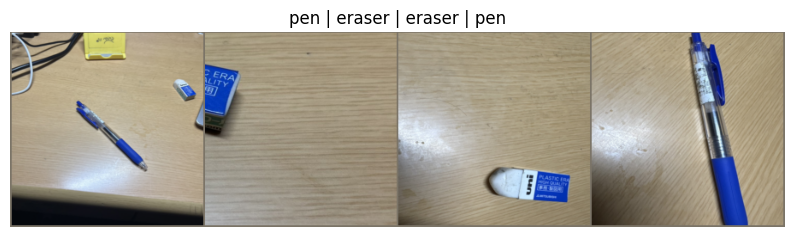

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torchvision

def imshow(inp, title=None):
    # Tensorを画像表示用に変換
    inp = inp.numpy().transpose((1, 2, 0))

    # Normalizeを元に戻す
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)

    plt.figure(figsize=(10, 5))
    plt.imshow(inp)

    if title is not None:
        plt.title(title)

    plt.axis("off")
    plt.show()


# train画像を1バッチ取得
inputs, classes = next(iter(dataloaders["train"]))

# 画像を並べて表示
grid = torchvision.utils.make_grid(inputs)

imshow(
    grid,
    title=" | ".join(class_names[x] for x in classes)
)

In [11]:
import time
import copy
import torch.nn as nn
import torch.optim as optim

from torch.optim import lr_scheduler
from torchvision import models
from torchvision.models import ResNet18_Weights


def train_model(
    model,
    criterion,
    optimizer,
    scheduler,
    num_epochs=10
):
    start_time = time.time()

    best_model_weights = copy.deepcopy(model.state_dict())
    best_accuracy = 0.0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 20)

        for phase in ["train", "val"]:

            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    predictions = torch.argmax(
                        outputs,
                        dim=1
                    )

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += (
                    loss.item() * inputs.size(0)
                )

                running_corrects += (
                    predictions == labels
                ).sum().item()

            if phase == "train":
                scheduler.step()

            epoch_loss = (
                running_loss / dataset_sizes[phase]
            )

            epoch_accuracy = (
                running_corrects / dataset_sizes[phase]
            )

            print(
                f"{phase} "
                f"Loss: {epoch_loss:.4f} "
                f"Acc: {epoch_accuracy:.4f}"
            )

            if (
                phase == "val"
                and epoch_accuracy > best_accuracy
            ):
                best_accuracy = epoch_accuracy
                best_model_weights = copy.deepcopy(
                    model.state_dict()
                )

        print()

    elapsed_time = time.time() - start_time

    print(
        f"Training complete in "
        f"{elapsed_time // 60:.0f}m "
        f"{elapsed_time % 60:.0f}s"
    )

    print(
        f"Best val Acc: {best_accuracy:.4f}"
    )

    model.load_state_dict(best_model_weights)

    return model

In [12]:
# 学習済みResNet18を読み込む
model_ft = models.resnet18(
    weights=ResNet18_Weights.DEFAULT
)

# 最後の分類層を2クラス用に変更
number_of_features = model_ft.fc.in_features

model_ft.fc = nn.Linear(
    number_of_features,
    len(class_names)
)

model_ft = model_ft.to(device)

# 損失関数
criterion = nn.CrossEntropyLoss()

# model_ftでは全パラメータを学習する
optimizer_ft = optim.SGD(
    model_ft.parameters(),
    lr=0.001,
    momentum=0.9
)

# 7エポックごとに学習率を小さくする
scheduler_ft = lr_scheduler.StepLR(
    optimizer_ft,
    step_size=7,
    gamma=0.1
)

# 学習開始
model_ft = train_model(
    model_ft,
    criterion,
    optimizer_ft,
    scheduler_ft,
    num_epochs=10
)

Epoch 1/10
--------------------
train Loss: 0.4798 Acc: 0.7667
val Loss: 0.1419 Acc: 1.0000

Epoch 2/10
--------------------
train Loss: 0.6261 Acc: 0.7333
val Loss: 0.3729 Acc: 0.8500

Epoch 3/10
--------------------
train Loss: 0.4793 Acc: 0.8500
val Loss: 0.0031 Acc: 1.0000

Epoch 4/10
--------------------
train Loss: 0.2383 Acc: 0.9333
val Loss: 0.0301 Acc: 1.0000

Epoch 5/10
--------------------
train Loss: 0.1540 Acc: 0.9333
val Loss: 0.0031 Acc: 1.0000

Epoch 6/10
--------------------
train Loss: 0.0354 Acc: 0.9833
val Loss: 0.0164 Acc: 1.0000

Epoch 7/10
--------------------
train Loss: 0.0916 Acc: 0.9667
val Loss: 0.0009 Acc: 1.0000

Epoch 8/10
--------------------
train Loss: 0.2965 Acc: 0.8667
val Loss: 0.0019 Acc: 1.0000

Epoch 9/10
--------------------
train Loss: 0.3179 Acc: 0.8667
val Loss: 0.0019 Acc: 1.0000

Epoch 10/10
--------------------
train Loss: 0.1068 Acc: 0.9333
val Loss: 0.0013 Acc: 1.0000

Training complete in 1m 1s
Best val Acc: 1.0000


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models
from torchvision.models import ResNet18_Weights
from torch.optim import lr_scheduler

In [14]:
# 学習済みResNet18を読み込む
model_conv = models.resnet18(
    weights=ResNet18_Weights.DEFAULT
)

# 畳み込み部分のパラメータを固定する
for parameter in model_conv.parameters():
    parameter.requires_grad = False

# 最後の分類層だけを2クラス用に変更する
number_of_features = model_conv.fc.in_features

model_conv.fc = nn.Linear(
    number_of_features,
    len(class_names)
)

model_conv = model_conv.to(device)

# 最後の分類層だけを学習する
optimizer_conv = optim.SGD(
    model_conv.fc.parameters(),
    lr=0.001,
    momentum=0.9
)

scheduler_conv = lr_scheduler.StepLR(
    optimizer_conv,
    step_size=7,
    gamma=0.1
)

# 学習開始
model_conv = train_model(
    model_conv,
    criterion,
    optimizer_conv,
    scheduler_conv,
    num_epochs=10
)

Epoch 1/10
--------------------
train Loss: 0.5335 Acc: 0.7500
val Loss: 0.2488 Acc: 1.0000

Epoch 2/10
--------------------
train Loss: 0.3500 Acc: 0.8500
val Loss: 0.0768 Acc: 1.0000

Epoch 3/10
--------------------
train Loss: 0.3290 Acc: 0.8667
val Loss: 0.0570 Acc: 1.0000

Epoch 4/10
--------------------
train Loss: 0.2558 Acc: 0.9000
val Loss: 0.0345 Acc: 1.0000

Epoch 5/10
--------------------
train Loss: 0.2267 Acc: 0.9333
val Loss: 0.0271 Acc: 1.0000

Epoch 6/10
--------------------
train Loss: 0.4095 Acc: 0.8500
val Loss: 0.1416 Acc: 1.0000

Epoch 7/10
--------------------
train Loss: 0.2460 Acc: 0.8833
val Loss: 0.0256 Acc: 1.0000

Epoch 8/10
--------------------
train Loss: 0.1508 Acc: 0.9667
val Loss: 0.0209 Acc: 1.0000

Epoch 9/10
--------------------
train Loss: 0.2095 Acc: 0.8667
val Loss: 0.0228 Acc: 1.0000

Epoch 10/10
--------------------
train Loss: 0.2359 Acc: 0.9167
val Loss: 0.0186 Acc: 1.0000

Training complete in 0m 21s
Best val Acc: 1.0000


Example 1
True label: eraser
Prediction by model_ft: eraser
Prediction by model_conv: eraser



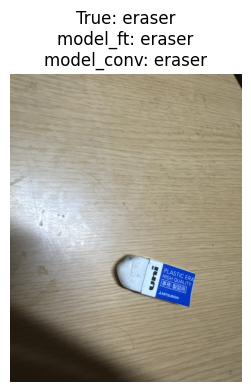

Example 2
True label: eraser
Prediction by model_ft: eraser
Prediction by model_conv: eraser



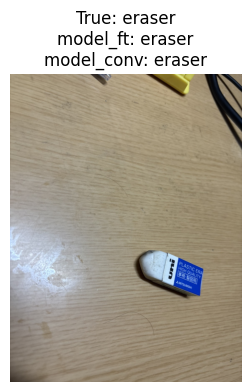

Example 3
True label: pen
Prediction by model_ft: pen
Prediction by model_conv: pen



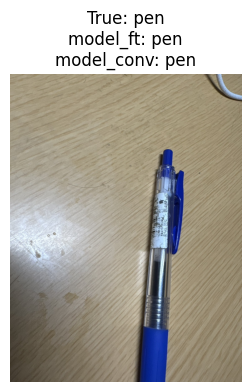

In [15]:
import os
import torch
import matplotlib.pyplot as plt
from PIL import Image


def predict_image(model, image_path):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    input_tensor = data_transforms["val"](image)
    input_tensor = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        predicted_index = outputs.argmax(dim=1).item()

    return class_names[predicted_index]


# val画像の一覧
val_samples = image_datasets["val"].samples

# 3枚選ぶ
example_indices = [0, 1, len(val_samples) // 2]

for example_number, sample_index in enumerate(
    example_indices,
    start=1
):
    image_path, true_index = val_samples[sample_index]

    true_label = class_names[true_index]
    prediction_ft = predict_image(
        model_ft,
        image_path
    )
    prediction_conv = predict_image(
        model_conv,
        image_path
    )

    image = Image.open(image_path).convert("RGB")

    print(f"Example {example_number}")
    print("True label:", true_label)
    print("Prediction by model_ft:", prediction_ft)
    print("Prediction by model_conv:", prediction_conv)
    print()

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"True: {true_label}\n"
        f"model_ft: {prediction_ft}\n"
        f"model_conv: {prediction_conv}"
    )
    plt.show()

---
# Report5A: Make your own classifier (Mandatory:必須)  

**Directly change "--" in this text cell to write a report.**

You are strongly encouraged to take images at your USB camera (or your smartphone camera).
(It is because the dataset would be obvious and trivial if you collect images by the google query with the word...)   
(DO NOT USE open dataset!)

* Show the link to the top google-drive folder of the image dataset (It should include train/Class1 train/Class2 val/Class1 val/Class2)

1. URL:https://drive.google.com/drive/folders/1-hA_tSHZxitlyQmIwuNE-czSTI-3pFJK?usp=drive_link
 -- (it should be accessible to kameda.yoshinari@image.iit.tsukuba.ac.jp / google account)

* Show the two class names you give.

1. Class1: --pen
2. Class2: --eraser

* Number of images

1. Class1: --train 30 images, validation 10 images, total 40 images
2. Class2: --train 30 images, validation 10 images, total 40 images

* Three examples of test results (true label, two predicted labels of model_ft and model_conv, image)

1. Example1: --
True label: eraser
Prediction by model_ft: eraser
Prediction by model_conv: eraser

2. Example2: --
True label: eraser
Prediction by model_ft: eraser
Prediction by model_conv: eraser
3. Example3: --
True label: pen
Prediction by model_ft: pen
Prediction by model_conv: pen


Images should be given by URL that is accesible by kameda.yoshinari.ft@u.tsukuba.ac.jp, or inline image).


Write your findings of Report5A (Any comments are OK) below.

--

---
# Report5X: Evaluate the performance by "test" dataset (Optional:発展)  

Prepare 10 test images that take either of the two class objects (or other if you prefer, in this case, the 3rd label should be "other") and measure the performance of the two classifiers (of model_ft and model_conv).

* The images should be placed at the same folder as shown in 5A. (e.g. test/Class1 test/Class2 test/other)
* The total number of images in test/ folder should be 10 or more.
* Show the accuracy for the 10 images for both model_ft and model_conv.
* Carefully write the table and the report so as to be easy to read.


Report of 5X should be placed by changing this text cell (you can add more cells if you need).

---
# Report5Y: Evaluate the performance by changing the training (and validation) dataset (Optional:発展)  

By changinge the number of the images in train / validation, show the classification ratio for each.

* The number changing policy is up to the student.
* Write the way to select the images.
* Discuss what you expect before you start and what actually happend in the experimental result.
* Guess the reason if you encounter the expectation does not become true.


Report of 5Y should be placed by changing this text cell (you can add more cells if you need).

---
# Report5Z: Hide the objects and see what happens on the classifiers (Optional:発展)  

You may think the classifier could be build even when the objects are deleted from the training images as the some peripheral areas might have the biased image property correlated to the object.

* Delete (black out) the objects roughly in the training images.
* Run the same process of 5A, and 5X / 5Y if possible.
* Discuss what you expect before you start and what actually happend in the experimental result.
* Justify the reason of what actually happend.

Further reading:


[Object Recognition with and without Objects (2016)](https://arxiv.org/abs/1611.06596)  
[Noise or Signal: The Role of Image Backgrounds in Object Recognition (2017)](https://arxiv.org/abs/2006.09994)  
  

A discussion before AI/DL age  
[物体検出 — 背景と検出対象のモデリング — (2005)](https://vision.kuee.kyoto-u.ac.jp/japanese/happyou/pdf/Sumi_2005_P_197.pdf)

Report of 5Z should be placed by changing this text cell (you can add more cells if you need).

---
# Report submission

The report template will be given in ipynb file.  

You should save this file as a report templete to your local google colaboratory folder and then edit it to fit your report.

The report submission should be made at this cource (0ALE005) at https://manaba.tsukuba.ac.jp .  
Note that 0AL5707 is coupled with 0ALE005 on manaba system, so 0AL5707 students should also submit the report at 0ALE005.  
File extension should be **ipynb**. Other format won't be accepted.  








---
Tools and Practices for Intelligent Interaction Systems A  
Master's and Docotal programs in intelligent and mechanical interaction systems, University of Tsukuba, Japan.  
KAMEDA Yoshinari, SHIBUYA Takeshi  

知能システムツール演習a  
知能機能システム学位プログラム (筑波大学大学院)  
担当：亀田能成，澁谷長史  

2026/08/03. Ver.A.  


